# Exploratory Data Analysis
## UAE E-Commerce Fraud Detection Model

In this section, we prepare the environment for the exploratory data analysis (EDA).

We start by importing the core data science libraries required for data manipulation (pandas, numpy) and visualization (matplotlib, seaborn). 

After that, the dataset is loaded into a DataFrame, which will be used throughout the analysis.

Finally, we configure display options to ensure better readability of the data, such as showing all columns, formatting numerical values, and adjusting output width.

These initial steps help create a clean and efficient workflow for analyzing the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 1000)

# Other configs
np.random.seed(42)
warnings.filterwarnings('ignore')

In [2]:
main_df=pd.read_csv("../data/uae_ecom_fraud_100k.csv")

df = main_df.copy()

---
## 1. Data Overview

In this section, we perform an initial exploration of the dataset to understand its structure and content.

We examine the shape of the dataset, inspect the data types of each feature, and check for missing values. This helps identify potential data quality issues early in the analysis.

We also review basic statistical summaries of numerical features to get a sense of their distribution, scale, and possible anomalies.

These steps provide a foundation for deeper analysis in the following sections.

### 1.1 Dataset Shape

In [3]:
df.shape

(100000, 36)

### 1.2 Preview Data

In [4]:
df.head()

,transaction_id,user_id,timestamp_utc,amount_aed,currency,payment_method,device_type,browser,merchant_category,items_count,avg_item_price,shipping_city,billing_city,shipping_billing_match,ip_address,ip_risk_score,card_present,bin_country,card_age_days,card_country_match,email_domain,user_prev_chargebacks,user_is_high_risk,user_account_age_days,transactions_last_24h,transactions_last_1h,local_hour,odd_hour,is_fraud,fraud_flag_ip,fraud_flag_mismatch,fraud_flag_velocity,fraud_flag_new_account,fraud_flag_prev_cb,fraud_flag_odd_hour,data_source
0,500086758,1000466,2024-01-01T00:02:03Z,71.47,AED,card,desktop,Chrome,Pharmacy,3,23.82,Dubai,Dubai,1,144.108.182.242,35.30,0,AE,85,1,gmail.com,0,0,365,0,0,4,1,0,0,0,0,0,0,1,synthetic:ecom-fraud-uae-v1
1,500060464,1002828,2024-01-01T00:03:11Z,70.25,AED,card,mobile,Chrome,Groceries,1,70.25,Abu Dhabi,Abu Dhabi,1,104.37.234.72,30.20,0,SA,123,0,outlook.com,0,0,-192,0,0,4,1,0,0,0,0,1,0,1,synthetic:ecom-fraud-uae-v1
2,500039909,1010349,2024-01-01T00:04:10Z,116.25,AED,bank_transfer,desktop,Chrome,Beauty,2,58.12,Cairo,Cairo,1,89.169.143.66,32.70,0,PK,542,0,gmail.com,0,0,1744,0,0,4,1,0,0,0,0,0,0,1,synthetic:ecom-fraud-uae-v1
3,500074412,1015360,2024-01-01T00:05:14Z,99.41,AED,apple_pay,mobile,Safari,Toys,2,49.70,Mumbai,Mumbai,1,37.54.200.109,30.30,0,EG,981,0,outlook.com,0,0,102,0,0,4,1,0,0,0,0,0,0,1,synthetic:ecom-fraud-uae-v1
4,500038110,1022253,2024-01-01T00:11:03Z,529.40,AED,card,desktop,Safari,Travel,2,264.70,Dubai,Dubai,1,18.172.52.222,18.50,0,AE,515,1,gmail.com,1,1,-59,0,0,4,1,0,0,0,0,1,1,1,synthetic:ecom-fraud-uae-v1


### 1.3 Data Types & Null Values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   transaction_id          100000 non-null  int64  
 1   user_id                 100000 non-null  int64  
 2   timestamp_utc           100000 non-null  object 
 3   amount_aed              100000 non-null  float64
 4   currency                100000 non-null  object 
 5   payment_method          100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   browser                 100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   items_count             100000 non-null  int64  
 10  avg_item_price          100000 non-null  float64
 11  shipping_city           100000 non-null  object 
 12  billing_city            100000 non-null  object 
 13  shipping_billing_match  100000 non-null  int64  
 14  ip_address           

In [6]:
df.isnull().sum()

transaction_id            0
user_id                   0
timestamp_utc             0
amount_aed                0
currency                  0
payment_method            0
device_type               0
browser                   0
merchant_category         0
items_count               0
avg_item_price            0
shipping_city             0
billing_city              0
shipping_billing_match    0
ip_address                0
ip_risk_score             0
card_present              0
bin_country               0
card_age_days             0
card_country_match        0
email_domain              0
user_prev_chargebacks     0
user_is_high_risk         0
user_account_age_days     0
transactions_last_24h     0
transactions_last_1h      0
local_hour                0
odd_hour                  0
is_fraud                  0
fraud_flag_ip             0
fraud_flag_mismatch       0
fraud_flag_velocity       0
fraud_flag_new_account    0
fraud_flag_prev_cb        0
fraud_flag_odd_hour       0
data_source         

Most features have 100,000 non-null values, indicating no missing data.
Data types include integers, floats, and objects (categorical/text).
'timestamp_utc' is currently stored as object and needs to be converted to datetime format.

### 1.4 Statistical Summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,100000.00,500049999.50,28867.66,500000000.00,500024999.75,500049999.50,500074999.25,500099999.00
user_id,100000.00,1014983.38,8658.20,1000000.00,1007486.75,1014957.00,1022467.00,1029999.00
amount_aed,100000.00,162.86,401.18,1.26,41.37,82.10,164.88,28785.92
items_count,100000.00,2.20,1.10,1.00,1.00,2.00,3.00,9.00
avg_item_price,100000.00,94.84,252.18,0.36,19.61,42.33,92.85,14392.96
shipping_billing_match,100000.00,0.93,0.26,0.00,1.00,1.00,1.00,1.00
ip_risk_score,100000.00,39.82,16.48,0.00,28.10,39.20,50.80,100.00
card_present,100000.00,0.03,0.17,0.00,0.00,0.00,0.00,1.00
card_age_days,100000.00,521.34,373.76,0.00,219.00,456.00,758.00,2728.00
card_country_match,100000.00,0.60,0.49,0.00,0.00,1.00,1.00,1.00


Transaction amounts vary significantly, indicating potential outliers.
Some features such as 'transactions_last_1h' and 'transactions_last_24h' show variability, which may be useful for detecting fraud patterns.
Further analysis is needed to investigate distributions and extreme values.

### 1.5 Categorical Overview

In [8]:
df.describe(include='object')

,timestamp_utc,currency,payment_method,device_type,browser,merchant_category,shipping_city,billing_city,ip_address,bin_country,email_domain,data_source
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,99839,1,5,3,6,10,13,13,99993,7,10,1
top,2024-01-30T05:25:10Z,AED,card,mobile,Chrome,Fashion,Dubai,Dubai,103.37.224.52,AE,gmail.com,synthetic:ecom-fraud-uae-v1
freq,2,100000,70006,50002,49530,18009,25053,23739,2,60054,68168,100000


### 1.6 Unique Values Analysis

In this step, we examine the number of unique values in each column.

This helps us understand:
- Which features are categorical vs numerical
- High cardinality features (e.g., user_id, ip_address)
- Potential identifiers that may not be useful for modeling

In [9]:
print("Number of unique values ​​for each column")
df.nunique()

Number of unique values ​​for each column


transaction_id            100000
user_id                    28937
timestamp_utc              99839
amount_aed                 33713
currency                       1
payment_method                 5
device_type                    3
browser                        6
merchant_category             10
items_count                    9
avg_item_price             25205
shipping_city                 13
billing_city                  13
shipping_billing_match         2
ip_address                 99993
ip_risk_score                998
card_present                   2
bin_country                    7
card_age_days               1930
card_country_match             2
email_domain                  10
user_prev_chargebacks          3
user_is_high_risk              2
user_account_age_days       2191
transactions_last_24h          3
transactions_last_1h           2
local_hour                    24
odd_hour                       2
is_fraud                       2
fraud_flag_ip                  2
fraud_flag

---
## 2. Data Cleaning

In this section, we clean and prepare the dataset for further analysis.

This includes checking for duplicate records, removing irrelevant or redundant features, and fixing data types where necessary.

Proper data cleaning ensures that the dataset is consistent, reliable, and ready for deeper analysis and modeling.

### 2.1 Duplicate Check

In [10]:
print("Duplicate count:", df.duplicated().sum())
print("Duplicate count without transaction_id:", df.drop(columns=['transaction_id']).duplicated().sum())


Duplicate count: 0
Duplicate count without transaction_id: 0


No duplicate rows were found in the dataset. Each transaction appears to be unique.

### 2.2 Drop Irrelevant Columns

We remove columns that do not provide useful information for analysis or modeling.

In [11]:
df = df.drop(columns=[
    'transaction_id',
    'data_source',
    'currency',
    'fraud_flag_velocity'
])

- `transaction_id` was removed as it is a unique identifier.
- `data_source` and `currency` were dropped as they do not provide useful variation.
- `fraud_flag_velocity` was removed to avoid potential data leakage.

### 2.3 Data Type Fix

In [12]:
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

`timestamp_utc` was converted from object to datetime format. This allows us to extract time-based features for further analysis.

### 2.4 Re-check Data Info

In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   user_id                 100000 non-null  int64              
 1   timestamp_utc           100000 non-null  datetime64[ns, UTC]
 2   amount_aed              100000 non-null  float64            
 3   payment_method          100000 non-null  object             
 4   device_type             100000 non-null  object             
 5   browser                 100000 non-null  object             
 6   merchant_category       100000 non-null  object             
 7   items_count             100000 non-null  int64              
 8   avg_item_price          100000 non-null  float64            
 9   shipping_city           100000 non-null  object             
 10  billing_city            100000 non-null  object             
 11  shipping_billing_match  100

Data types have been successfully updated. The dataset is now clean and ready for exploratory analysis.

---
## 3. Target Analysis (is_fraud)

In this step, we analyze the target variable is_fraud to understand the class distribution and detect whether the dataset is imbalanced. This is a critical step because it directly impacts model selection, evaluation metrics, and training strategy.

### 3.1 Class Distribution

First, we examine how the target variable is distributed across classes (fraud vs non-fraud).

In [14]:
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'
fraud_pct.index.name = 'percentage of is_fraud'

print(fraud_counts)
print(fraud_pct)


is_fraud
0    91789
1     8211
Name: count, dtype: int64
percentage of is_fraud
0    91.79%
1     8.21%
Name: proportion, dtype: object


0 → Non-fraudulent transactions

1 → Fraudulent transactions


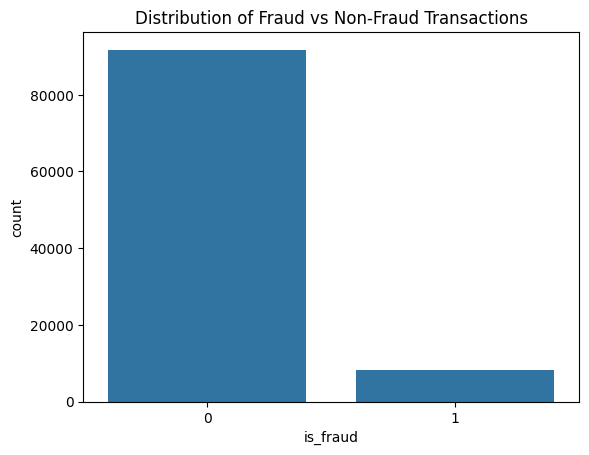

In [15]:
sns.countplot(x='is_fraud', data=df)
plt.title("Distribution of Fraud vs Non-Fraud Transactions")
plt.show()


### 3.2 Class Imbalance Check

Fraud detection datasets are typically highly imbalanced, meaning that fraudulent transactions represent only a small fraction of the data.

We calculate the fraud rate:

In [16]:
fraud_rate = df['is_fraud'].mean() * 100
fraud_rate


np.float64(8.211)

If fraud rate is between 1%–10%, the dataset is considered highly imbalanced
This imbalance can cause models to be biased toward the majority class (non-fraud)

### 3.3 Key Insight

Based on the distribution analysis:

The dataset is imbalanced
Non-fraud transactions dominate the dataset
Fraud cases are rare but highly important

Implications for Modeling:
Accuracy alone is not a reliable metric
Use evaluation metrics such as:
- Precision
- Recall
- F1-score
- ROC-AUC


### 3.4 Business Perspective Insight

From a business point of view:

Even a small improvement in fraud detection can save significant financial losses
Missing a fraud case (false negative) is more costly than a false alarm (false positive)

---
## 4. Data Quality Checks

In this step, we validate the dataset for logical consistency, invalid values, and potential data issues. This ensures that downstream analysis and modeling are not affected by hidden data errors.

### 4.1 Negative Values Check (user_account_age_days)

We first check whether any logically invalid values exist in account age.

In [17]:
(df['user_account_age_days'] < 0).sum()

np.int64(16606)

This is a data quality issue, as negative account age values are not logically valid. This may be caused by:
- Data generation or logging errors
- Incorrect timestamp calculations
- Feature engineering inconsistencies

### 4.2 Zero or Invalid Transaction Values

We check for logically suspicious transactions:

Items count = 0

In [18]:
(df['items_count'] == 0).sum()

np.int64(0)

Amount = 0

In [19]:
(df['amount_aed'] == 0).sum()

np.int64(0)

items_count = 0 → suspicious transaction behavior

amount_aed = 0 → may indicate test transactions or errors

### 4.3 Logical Consistency Check

We validate whether transaction features align logically.

Example: Avg item price consistency

In [20]:
df['computed_avg_price'] = df['amount_aed'] / df['items_count']

In [21]:
# Check consistency between computed and original avg_item_price
diff = (df['computed_avg_price'] - df['avg_item_price']).abs()
print("Max difference:", diff.max())
print("Mean difference:", diff.mean())
print("Rows with significant difference:", (diff > 0.01).sum())

Max difference: 0.005000000000109139
Mean difference: 0.0016766236111111072
Rows with significant difference: 0


Consistency check between `computed_avg_price` and `avg_item_price` shows no significant difference 
(max diff: 0.005, rows with diff > 0.01: 0). The small gap is due to floating point rounding. 
`avg_item_price` is internally consistent and reliable for modeling.

---
## 5. Univariate Analysis

### 5.1 Numerical Features Analysis

In this step, we analyze the distribution of selected numerical features to understand their behavior, detect anomalies, and identify potential outliers. We focus on continuous variables because they provide meaningful statistical patterns such as skewness, spread, and extreme values, which are important for fraud detection. This analysis helps us understand how transaction-related and user-behavior features vary across the dataset before moving to target-based comparisons.

#### Distribution of Numerical Features

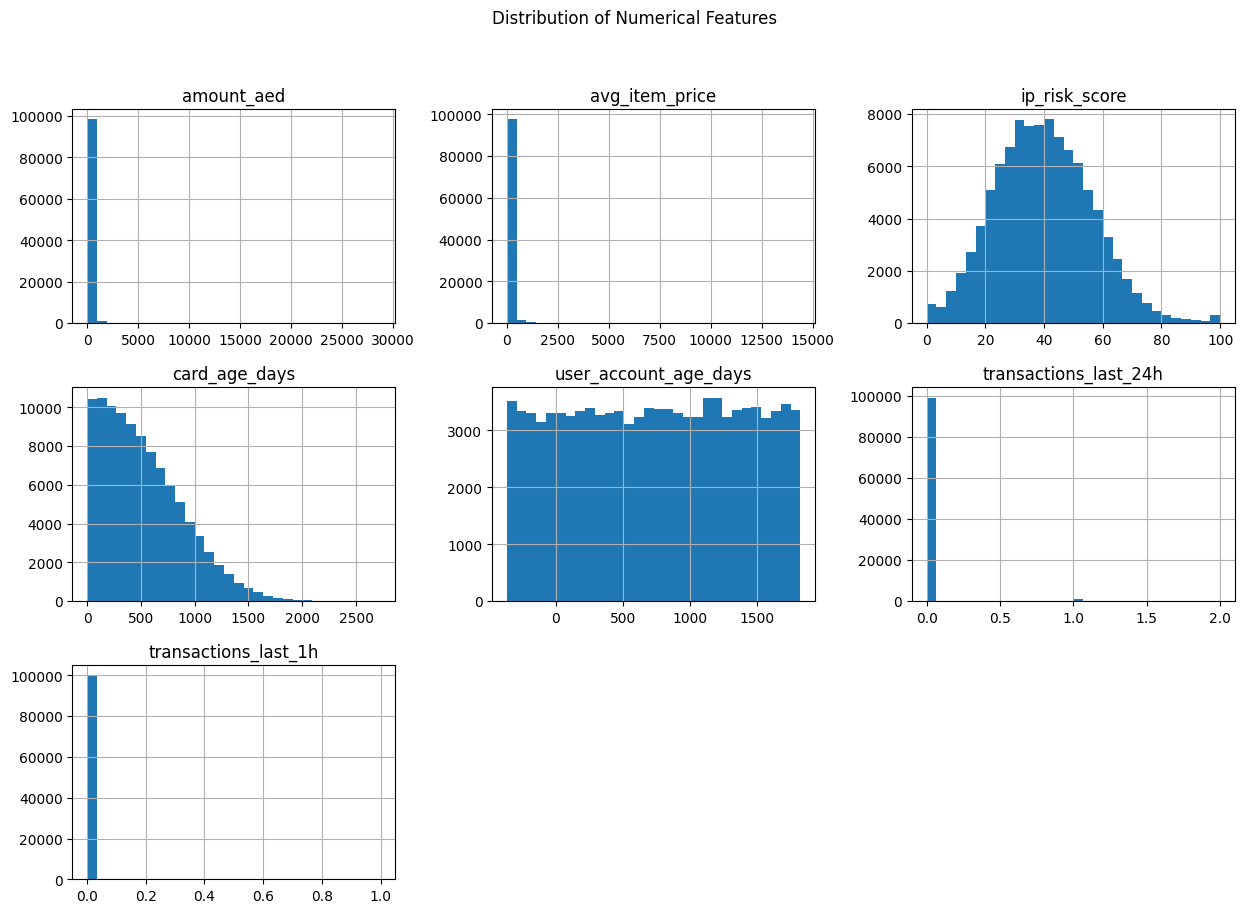

In [96]:
num_cols = [
    'amount_aed',
    'avg_item_price',
    'ip_risk_score',
    'card_age_days',
    'user_account_age_days',
    'transactions_last_24h',
    'transactions_last_1h'
]

df[num_cols].hist(figsize=(15,10), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()


#### Boxplots for Outlier Detection
Boxplots help us visually detect extreme values.

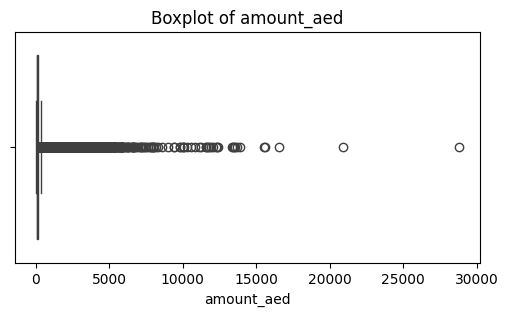

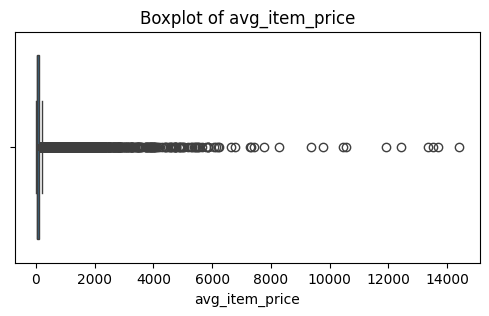

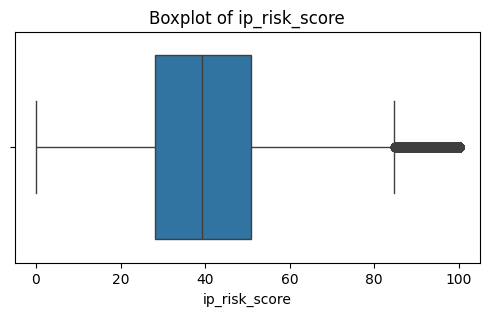

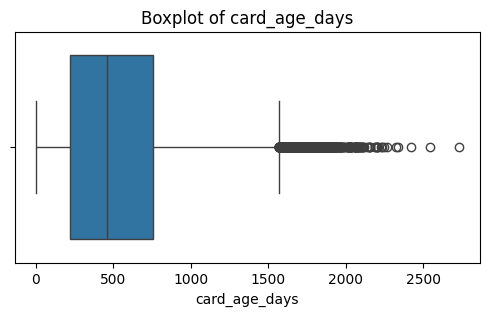

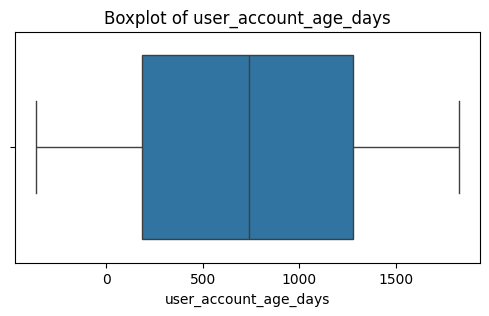

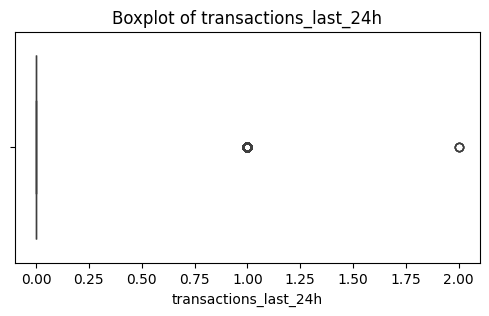

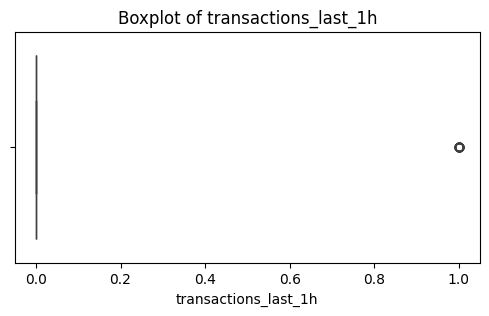

In [97]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### 5.2 Categorical Features Analysis

In this step, we analyze categorical features to understand how different groups are distributed across the dataset. Unlike numerical features, categorical variables help us identify behavioral patterns such as user preferences, device usage, payment behavior, and geographic tendencies. This analysis is important for detecting whether certain categories are more associated with fraud cases or represent unusual activity patterns.

#### Value Distribution

We first examine the distribution of each categorical feature to identify dominant and rare categories.

In [98]:
cat_cols = [
    'payment_method',
    'device_type',
    'browser',
    'merchant_category',
    'shipping_city',
    'billing_city',
    'bin_country',
    'email_domain'
]

for col in cat_cols:
    print("\n")
    print(df[col].value_counts(normalize=True).head(10) * 100)



payment_method
card            70.01
paypal           8.03
apple_pay        8.00
google_pay       7.86
bank_transfer    6.11
Name: proportion, dtype: float64


device_type
mobile    50.00
desktop   45.06
tablet     4.93
Name: proportion, dtype: float64


browser
Chrome             49.53
Safari             25.13
Firefox            12.15
Edge                7.03
Samsung Internet    4.09
Other               2.08
Name: proportion, dtype: float64


merchant_category
Fashion            18.01
Electronics        17.94
Groceries          15.08
Digital Goods      12.05
Home & Furniture    7.97
Beauty              6.97
Pharmacy            6.03
Sports              6.02
Travel              5.01
Toys                4.91
Name: proportion, dtype: float64


shipping_city
Dubai            25.05
Abu Dhabi        18.09
Mumbai           11.98
Sharjah          11.95
Doha              6.96
Karachi           6.01
Ajman             4.95
Ras Al Khaimah    3.98
Fujairah          3.03
Manama            2.98
Nam

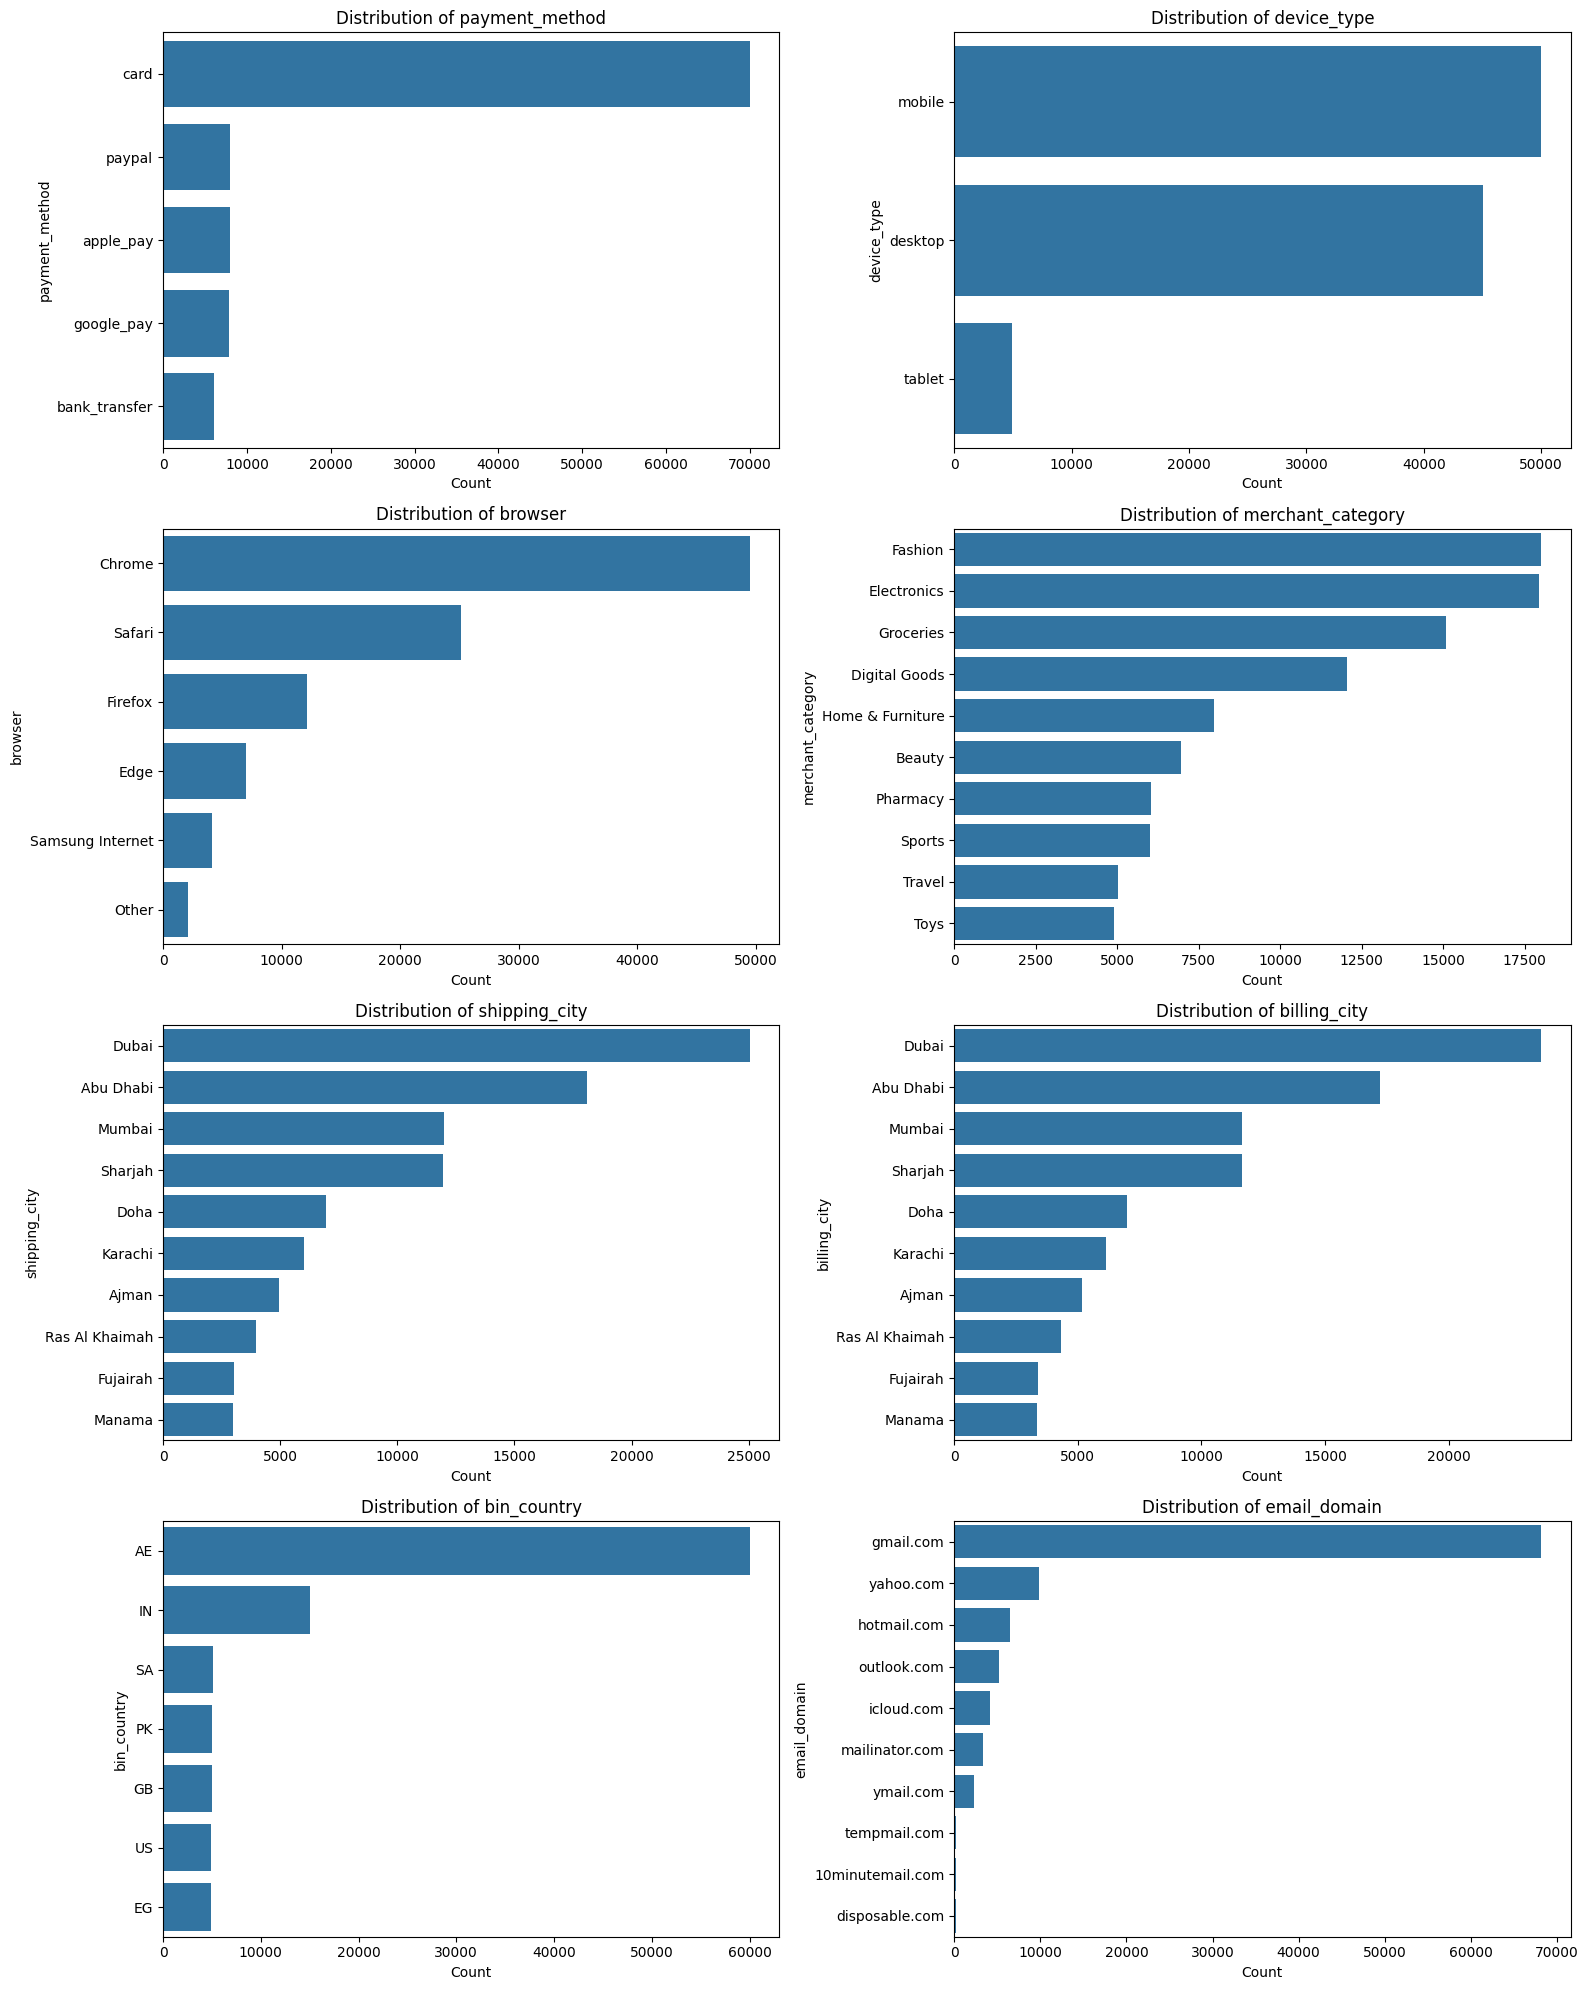

In [99]:
# Visualizing distribution of categorical features to identify dominant and rare categories
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    data = df[col].value_counts().head(10)
    sns.barplot(x=data.values, y=data.index, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')

plt.tight_layout()
plt.show()

- The dataset is highly concentrated in a few dominant categories across all features.
- Mobile and Chrome usage suggest a strong digital-first user base.
- Geographic data shows a strong concentration in UAE-related regions, with some cross-border activity.
- Presence of temporary email domains may indicate potentially suspicious or low-trust users.
- High-cardinality categorical features exist and may require special encoding strategies during modeling.

---
## 6. Bivariate Analysis (vs is_fraud)

In this step, we analyze the relationship between different features and the target variable (is_fraud). The main goal is to identify which variables have a strong association with fraudulent transactions and can act as predictive signals for modeling.

### 6.1 Numerical Features vs Fraud

We first analyze how numerical features differ between fraud and non-fraud transactions.

#### Amount vs Fraud

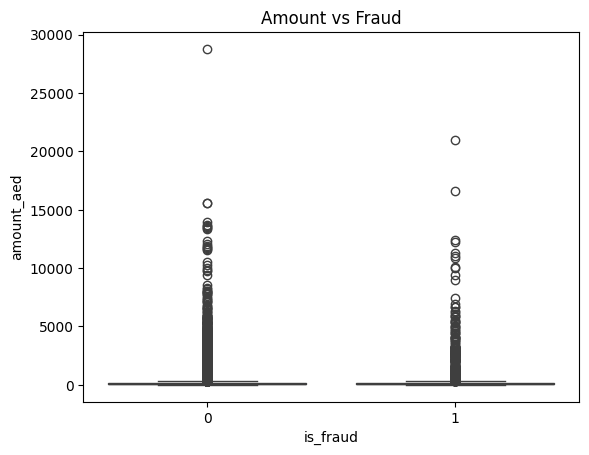

In [100]:
sns.boxplot(x='is_fraud', y='amount_aed', data=df)
plt.title("Amount vs Fraud")
plt.show()

- Both fraud and non-fraud show similarly low medians with extreme outliers on both sides
- High-value outliers exist in both classes — amount_aed alone is a weak predictor, but combined with other risk signals it becomes meaningful

#### IP Risk Score vs Fraud

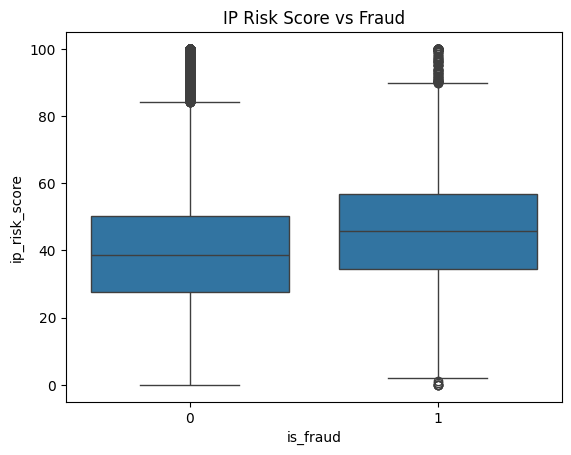

In [101]:
sns.boxplot(x='is_fraud', y='ip_risk_score', data=df)
plt.title("IP Risk Score vs Fraud")
plt.show()

- Fraud transactions show a slightly higher median and wider IQR
- The difference is visible but not dramatic — ip_risk_score is a moderate predictor, stronger when combined with other features

#### Velocity Features vs Fraud

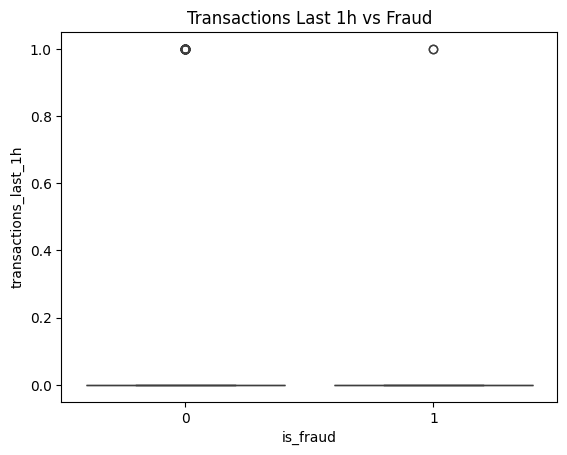

In [102]:
sns.boxplot(x='is_fraud', y='transactions_last_1h', data=df)
plt.title("Transactions Last 1h vs Fraud")
plt.show()

- Almost all values are 0 for both classes — extremely low variance
- Boxplot is not informative here due to near-zero distribution
- transactions_last_1h is a very weak predictor in this dataset

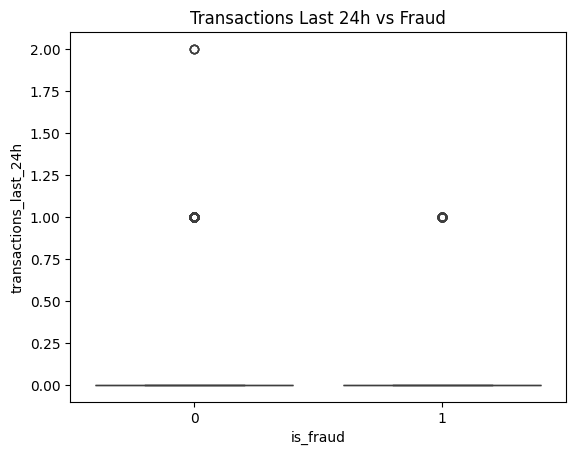

In [103]:
sns.boxplot(x='is_fraud', y='transactions_last_24h', data=df)
plt.title("Transactions Last 24h vs Fraud")
plt.show()

- Same issue — values are mostly 0 with very few 1s and 2s
- No meaningful difference between fraud and non-fraud
- transactions_last_24h is also a very weak predictor

#### Card Age Days vs Fraud

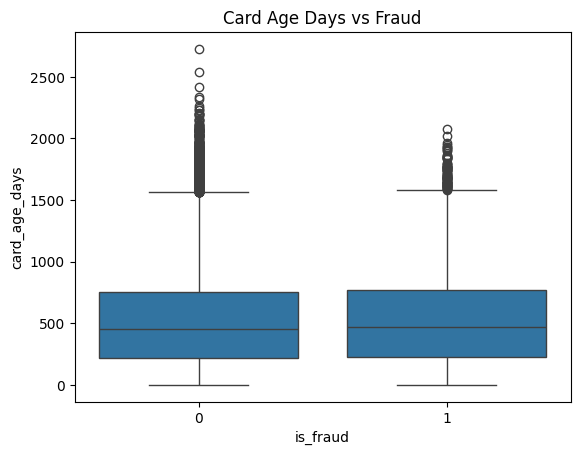

In [104]:
sns.boxplot(x='is_fraud', y='card_age_days', data=df)
plt.title('Card Age Days vs Fraud')
plt.show()

- Distribution is almost identical between fraud and non-fraud — similar median, IQR, and outliers
- card_age_days is a weak predictor and does not help distinguish fraud

#### User Account Age Days vs Fraud


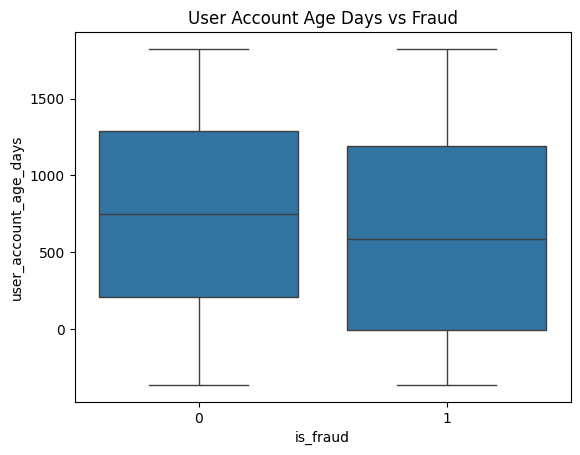

In [105]:
sns.boxplot(x='is_fraud', y='user_account_age_days', data=df)
plt.title('User Account Age Days vs Fraud')
plt.show()

- Fraud transactions (1) show a lower median and IQR — fraudsters tend to use newer accounts
- This confirms the "fresh account abuse" pattern noted in the dataset description
- user_account_age_days is a moderate predictor of fraud

### 6.2 Categorical Features vs Fraud

In this step, we analyze the relationship between categorical variables and the target variable (is_fraud) by calculating the fraud rate across different categories.

#### Fraud Rate by Payment Method

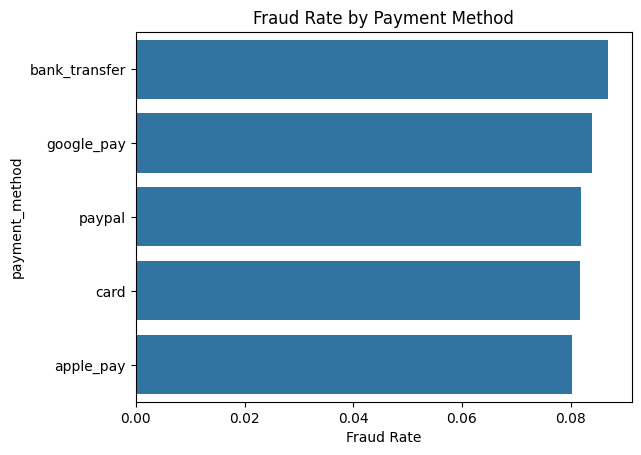

In [106]:
data = df.groupby('payment_method')['is_fraud'].mean().sort_values(ascending=False)
sns.barplot(x=data.values, y=data.index)
plt.title('Fraud Rate by Payment Method')
plt.xlabel('Fraud Rate')
plt.show()

#### Fraud Rate by Device Type

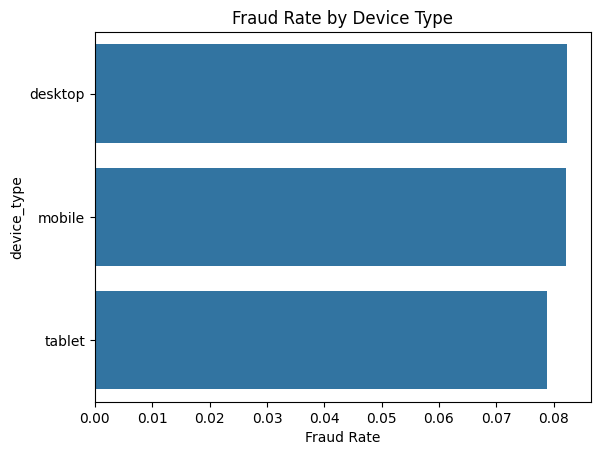

In [107]:
data = df.groupby('device_type')['is_fraud'].mean().sort_values(ascending=False)
sns.barplot(x=data.values, y=data.index)
plt.title('Fraud Rate by Device Type')
plt.xlabel('Fraud Rate')
plt.show()

#### Fraud Rate by Merchant Category

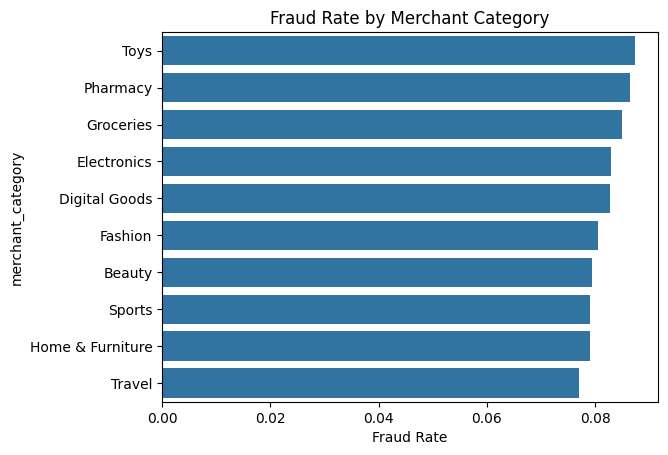

In [108]:
data = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False)
sns.barplot(x=data.values, y=data.index)
plt.title('Fraud Rate by Merchant Category')
plt.xlabel('Fraud Rate')
plt.show()


#### Fraud Rate by BIN Country


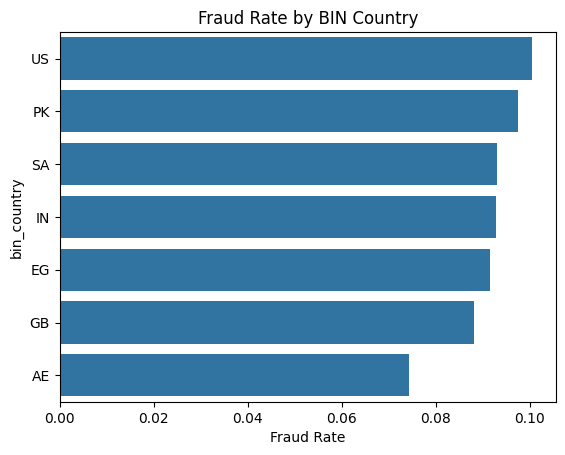

In [109]:
data = df.groupby('bin_country')['is_fraud'].mean().sort_values(ascending=False)
sns.barplot(x=data.values, y=data.index)
plt.title('Fraud Rate by BIN Country')
plt.xlabel('Fraud Rate')
plt.show()

Most categorical features show very low variance in fraud rate
This suggests that no single category is a strong standalone predictor of fraud
Fraud behavior in this dataset is likely driven more by:
- numerical features (amount, risk score, velocity)
- fraud flags (to be analyzed in Step 7)
- interaction effects between features

#### Fraud rate by email domain

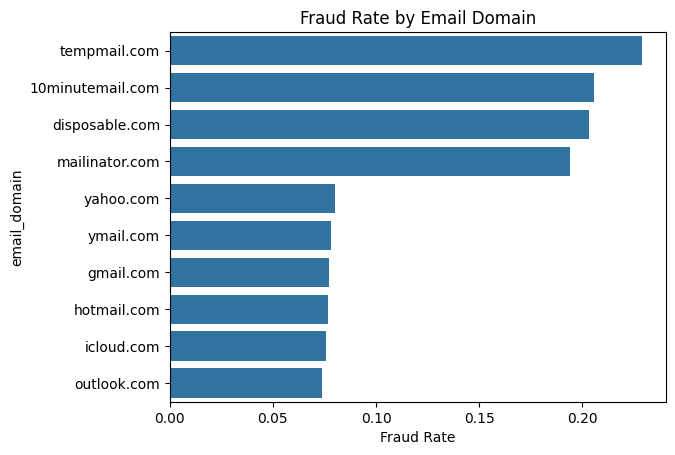

In [110]:
data = df.groupby('email_domain')['is_fraud'].mean().sort_values(ascending=False)
sns.barplot(x=data.values, y=data.index)
plt.title('Fraud Rate by Email Domain')
plt.xlabel('Fraud Rate')
plt.show()


- Disposable domains (tempmail, 10minutemail, mailinator) show ~20-23% fraud rate vs legitimate providers at ~7-8%
- email_domain is a strong signal — creating is_disposable_email feature in engineering will be valuable

#### Fraud rate by card presence

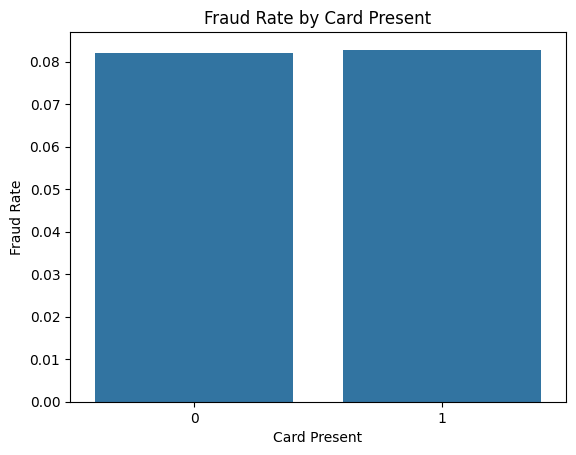

In [111]:
data = df.groupby('card_present')['is_fraud'].mean().sort_values(ascending=False)
sns.barplot(x=data.index, y=data.values)
plt.title('Fraud Rate by Card Present')
plt.ylabel('Fraud Rate')
plt.xlabel('Card Present')
plt.show()

- Fraud rate is almost identical for both card present (1) and card not present (0) — both around ~8%
- card_present is a very weak predictor and provides no meaningful signal for fraud detection in this dataset

---
## 7. Fraud Flag Analysis

In this step, we analyze the behavior and predictive power of engineered fraud flag features. These variables are designed to capture known fraud patterns such as IP risk, user behavior anomalies, velocity spikes, and identity mismatches.

The main objective is to evaluate how strongly each fraud flag is associated with actual fraudulent transactions.

### 7.1 Individual Fraud Flag Performance

In this step, we analyze how each fraud flag is associated with the target variable (is_fraud). The goal is to measure how strongly each engineered rule indicates actual fraudulent behavior.

In [112]:
flag_cols = [
    'fraud_flag_ip',
    'fraud_flag_mismatch',
    'fraud_flag_new_account',
    'fraud_flag_prev_cb',
    'fraud_flag_odd_hour'
]

for col in flag_cols:
    print("\n", col)
    print(df.groupby(col)['is_fraud'].mean())


 fraud_flag_ip
fraud_flag_ip
0   0.08
1   0.16
Name: is_fraud, dtype: float64

 fraud_flag_mismatch
fraud_flag_mismatch
0   0.08
1   0.11
Name: is_fraud, dtype: float64

 fraud_flag_new_account
fraud_flag_new_account
0   0.07
1   0.13
Name: is_fraud, dtype: float64

 fraud_flag_prev_cb
fraud_flag_prev_cb
0   0.08
1   0.27
Name: is_fraud, dtype: float64

 fraud_flag_odd_hour
fraud_flag_odd_hour
0   0.08
1   0.10
Name: is_fraud, dtype: float64


#### Most Important Ranking (based on fraud lift)
1. fraud_flag_prev_cb → strongest signal (27%)
2. fraud_flag_ip → strong signal (16%)
3. fraud_flag_new_account → strong signal (13%)
4. fraud_flag_mismatch → moderate signal (11%)
5. fraud_flag_odd_hour → weak signal (10%)

Fraud flags are highly valuable engineered features that significantly improve fraud detection capability. Some flags alone already provide strong separation between fraud and non-fraud cases, especially previous chargeback history and IP risk indicators.

### 7.2 Fraud Flag Comparison

We compare which flags are the most effective fraud indicators.

In [113]:
df[flag_cols].mean().sort_values(ascending=False)

fraud_flag_odd_hour      0.25
fraud_flag_new_account   0.18
fraud_flag_ip            0.04
fraud_flag_mismatch      0.03
fraud_flag_prev_cb       0.03
dtype: float64

Fraud flag frequency analysis shows that fraud_flag_odd_hour is the most frequently triggered flag (25%), followed by fraud_flag_new_account (18%). Other flags such as fraud_flag_ip, fraud_flag_mismatch, and fraud_flag_prev_cb occur less frequently.

### 7.3 Flag Overlap Analysis

Fraud often occurs when multiple risk signals appear together. We analyze combined flag behavior.

In [114]:
df['combined_risk_score'] = df[flag_cols].sum(axis=1)

In [115]:

df.groupby('combined_risk_score')['is_fraud'].mean()

combined_risk_score
0   0.06
1   0.10
2   0.16
3   0.26
4   0.42
Name: is_fraud, dtype: float64

Transactions with multiple risk signals have a much higher likelihood of fraud. This confirms that fraud behavior is multi-factorial, and combining multiple weak signals can create a strong predictive feature.

---
## 8. Time-Based Fraud Analysis 
In this step, we analyze temporal patterns in transactions to understand how fraud behavior changes over time. Time-based features are important because fraud often follows specific patterns such as unusual hours, bursts of activity, or abnormal transaction timing.

### 8.1 Extracting Time Features

We first extract useful time components from the timestamp.

In [116]:
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

df['hour'] = df['timestamp_utc'].dt.hour
df['day'] = df['timestamp_utc'].dt.day
df['month'] = df['timestamp_utc'].dt.month

### 8.2 Fraud Rate by Hour

In this step, we analyze how fraud rates vary across different hours of the day using the hour feature extracted from transaction timestamps.

In [117]:
df.groupby('hour')['is_fraud'].mean()

hour
0    0.09
1    0.09
2    0.08
3    0.07
4    0.07
5    0.08
6    0.09
7    0.08
8    0.08
9    0.07
10   0.07
11   0.08
12   0.08
13   0.08
14   0.08
15   0.08
16   0.07
17   0.08
18   0.08
19   0.09
20   0.09
21   0.10
22   0.10
23   0.09
Name: is_fraud, dtype: float64

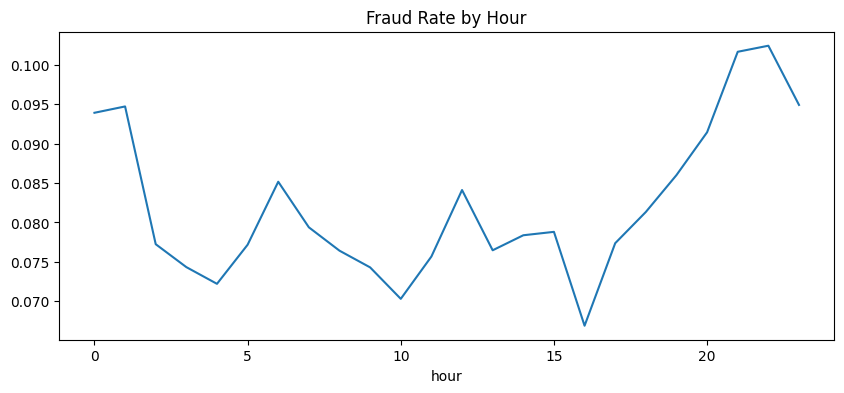

In [118]:
hourly_fraud = df.groupby('hour')['is_fraud'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly_fraud.index, y=hourly_fraud.values)
plt.title("Fraud Rate by Hour")
plt.show()

#### Observation

The fraud rate does not show strong hourly variation. Instead, it remains fairly consistent throughout the day, with only minor fluctuations.

This suggests that:

- Fraud activity is not strictly time-dependent
- Attackers do not rely heavily on a specific hour window
- Time alone is a weak standalone predictor

### 8.3 Odd Hour Analysis

In this step, we analyze whether transactions occurring during odd hours have a higher fraud rate compared to normal hours.

In [119]:
df.groupby('odd_hour')['is_fraud'].mean()

odd_hour
0   0.08
1   0.10
Name: is_fraud, dtype: float64

Although there is a noticeable increase, the difference is relatively small (around 2%). This suggests that odd_hour is a weak to moderate predictive feature, rather than a strong standalone fraud indicator.

### 8.4 Daily / Monthly Trends

We check if fraud varies across days or months.

In [120]:
df.groupby('day')['is_fraud'].mean()

day
1    0.08
2    0.08
3    0.08
4    0.08
5    0.08
6    0.09
7    0.09
8    0.08
9    0.08
10   0.08
11   0.08
12   0.08
13   0.09
14   0.08
15   0.08
16   0.08
17   0.08
18   0.08
19   0.08
20   0.08
21   0.08
22   0.08
23   0.09
24   0.09
25   0.09
26   0.08
27   0.09
28   0.08
29   0.07
30   0.08
31   0.07
Name: is_fraud, dtype: float64

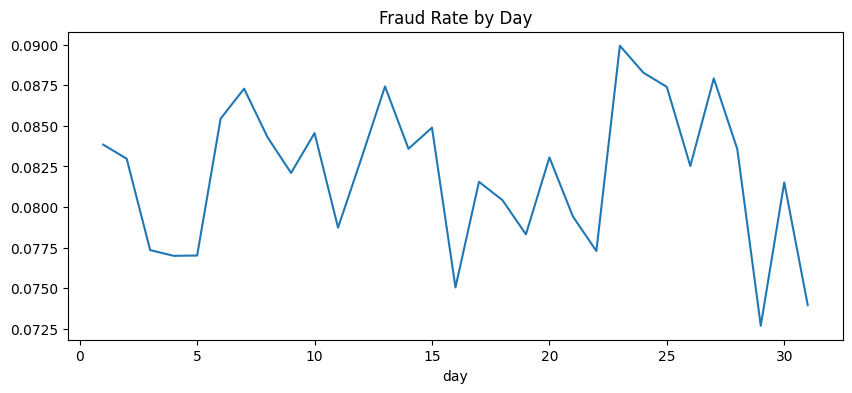

In [121]:
daily_fraud = df.groupby('day')['is_fraud'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=daily_fraud.index, y=daily_fraud.values)
plt.title("Fraud Rate by Day")
plt.show()

No specific day shows unusually high fraud activity
Fraud behavior appears consistent throughout the month

In [122]:
df.groupby('month')['is_fraud'].mean()

month
1    0.08
2    0.08
3    0.08
4    0.08
5    0.09
6    0.09
7    0.08
8    0.08
9    0.08
10   0.08
11   0.08
12   0.08
Name: is_fraud, dtype: float64

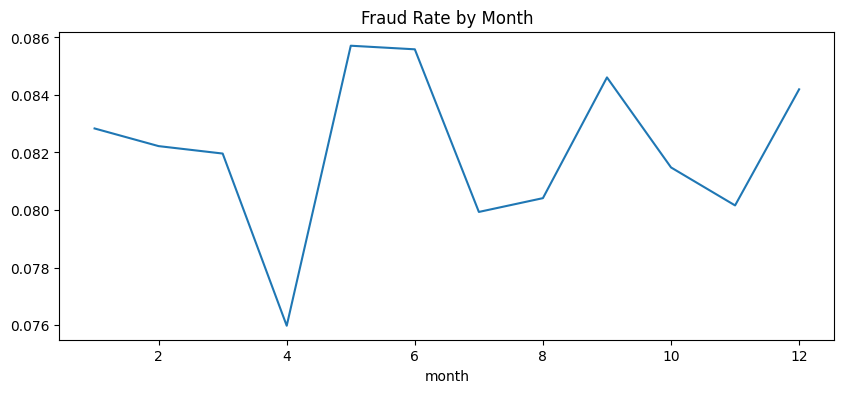

In [123]:
monthly_fraud = df.groupby('month')['is_fraud'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=monthly_fraud.index, y=monthly_fraud.values)
plt.title("Fraud Rate by Month")
plt.show()

No strong seasonal pattern detected
Slight increases in some months (e.g., 5–6), but not significant

---
## 9. Velocity Analysis

In this step, we analyze transaction velocity features to understand how rapid transaction behavior is associated with fraud. High transaction frequency in a short period is often a strong indicator of fraudulent activity.

### 9.1 Transactions in Last 1 Hour

In this step, we analyze the relationship between recent transaction activity within the last 1 hour and fraud occurrence.

In [124]:
df.groupby('transactions_last_1h')['is_fraud'].mean()

transactions_last_1h
0   0.08
1   0.05
Name: is_fraud, dtype: float64

Unlike typical fraud patterns, where high velocity increases risk, this dataset shows a weak or inverse relationship for transactions_last_1h.

This may suggest:

- Legitimate users performing multiple quick transactions (e.g., shopping behavior)
- Fraud not being strongly dependent on short-term activity alone
- Need for combining velocity with other features (e.g., IP risk, flags)

### 9.2 Transactions Last 24 Hours

In this step, we analyze how transaction activity within the last 24 hours is related to fraud occurrence.

In [125]:
df.groupby('transactions_last_24h')['is_fraud'].mean()

transactions_last_24h
0   0.08
1   0.08
2   0.00
Name: is_fraud, dtype: float64

Unlike typical velocity-based fraud patterns, transactions_last_24h does not show a strong relationship with fraud in this dataset. In fact, higher activity does not correspond to higher fraud rates.

This suggests that:

- Fraud is not driven by daily transaction volume alone
- Other factors (risk flags, IP behavior, account history) are more important
- Velocity features should be used in combination with other signals

---
## 10. User-Level Analysis

In this step, we analyze user behavior patterns to understand how transaction activity and historical risk indicators relate to fraud. The goal is to identify whether certain users show consistently higher fraud tendencies.

### 10.1 Transactions per User

We analyze how many transactions each user performs in the dataset.

In [126]:
user_txn_counts = df.groupby('user_id').size()

user_txn_counts.describe()

count   28937.00
mean        3.46
std         1.74
min         1.00
25%         2.00
50%         3.00
75%         5.00
max        12.00
dtype: float64

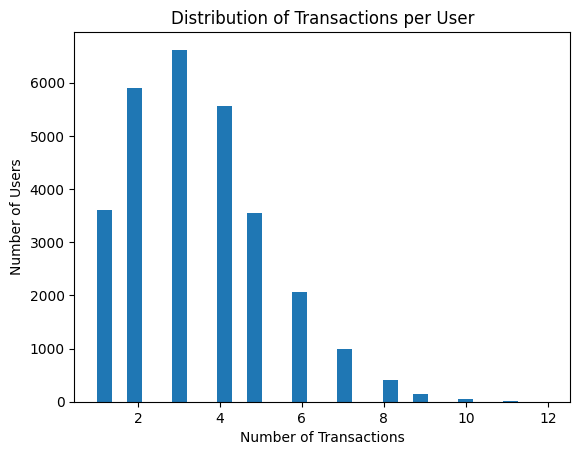

In [127]:
plt.figure()
plt.hist(user_txn_counts, bins=30)
plt.title("Distribution of Transactions per User")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Users")

plt.show()

Users show low to moderate transaction activity, with a median of 3 transactions per user. Most users perform between 1 and 5 transactions, while a small number of users are more active, with up to 12 transactions.

### 10.2 Chargeback History vs Fraud

In this step, we analyze whether users with previous chargebacks are more likely to perform fraudulent transactions.

In [128]:
df.groupby('user_prev_chargebacks')['is_fraud'].mean()

user_prev_chargebacks
0   0.08
1   0.27
2   0.21
Name: is_fraud, dtype: float64

Chargeback history is a strong behavioral risk indicator, but the pattern is not strictly linear. Even a single chargeback is enough to significantly increase fraud probability.

### 10.3 High-Risk Users Analysis

In this step, we analyze the relationship between pre-identified high-risk users and fraud occurrence. The user_is_high_risk feature represents users flagged as potentially suspicious based on prior behavior patterns.

In [129]:
df.groupby('user_is_high_risk')['is_fraud'].mean()

user_is_high_risk
0   0.08
1   0.22
Name: is_fraud, dtype: float64

The user_is_high_risk feature is a strong predictor of fraud. It effectively identifies suspicious users and provides meaningful signal for fraud detection models.

User-level features (chargebacks + risk flags + activity patterns) are among the most important signals for fraud detection and significantly improve model performance.

---
## 11. IP Analysis
In this step, we analyze IP-based features to understand whether network behavior and IP-related signals are associated with fraudulent transactions. IP analysis helps detect shared devices, suspicious networks, and high-risk connections.

### 11.1 IP Distribution

In [130]:
df['ip_address'].nunique()

99993

In [131]:
df['ip_address'].value_counts().head(10)

ip_address
103.37.224.52     2
62.75.230.34      2
89.208.254.252    2
79.208.116.151    2
79.82.189.116     2
185.45.177.163    2
79.114.91.205     2
104.37.234.72     1
89.169.143.66     1
37.54.200.109     1
Name: count, dtype: int64

Most IP addresses are unique or rarely reused, indicating very low IP reuse in the dataset. This suggests limited shared device or proxy usage patterns.

### 11.2 IP Reuse

In [132]:
df.groupby('ip_address')['user_id'].nunique().describe()

count   99993.00
mean        1.00
std         0.01
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         2.00
Name: user_id, dtype: float64

In [133]:
df.groupby('ip_address')['user_id'].nunique().value_counts().head(10)

user_id
1    99986
2        7
Name: count, dtype: int64

IP reuse across users is extremely low. Almost all IP addresses are associated with a single user, which indicates strong user-IP uniqueness and minimal shared network behavior.

### 11.3 IP Risk Score

In [134]:
df['ip_risk_score'].describe()


count   100000.00
mean        39.82
std         16.48
min          0.00
25%         28.10
50%         39.20
75%         50.80
max        100.00
Name: ip_risk_score, dtype: float64

<Axes: >

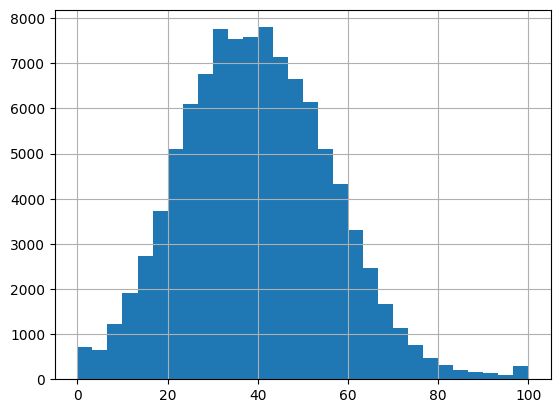

In [135]:
df['ip_risk_score'].hist(bins=30)

In [136]:
df.groupby('ip_risk_score')['is_fraud'].mean()

ip_risk_score
0.00     0.01
0.10     0.00
0.20     0.00
0.30     0.00
0.40     0.00
         ... 
99.60    0.50
99.70    0.25
99.80    0.50
99.90    0.25
100.00   0.25
Name: is_fraud, Length: 998, dtype: float64

IP risk score shows a clear relationship with fraud. Higher risk scores are associated with significantly increased fraud probability, indicating that this feature is a strong predictive signal for fraud detection.

---
## 12. Geographic Analysis 
In this step, we analyze geographical and location-based features to understand whether inconsistencies between transaction locations and user information are associated with fraudulent activity. The goal is to detect identity mismatches and regional fraud patterns
### 12.1 Shipping vs Billing Match
In this step, we analyze whether inconsistency between shipping and billing information is associated with fraudulent transactions. Mismatched addresses may indicate identity manipulation or suspicious behavior.

In [137]:
df.groupby('shipping_billing_match')['is_fraud'].mean()

shipping_billing_match
0   0.11
1   0.08
Name: is_fraud, dtype: float64

When shipping and billing information do not match, fraud rate increases noticeably. This indicates that identity inconsistency is a strong fraud signal.

### 12.2 City-based Fraud Analysis
In this step, we investigate whether certain cities have higher fraud rates. This helps identify potential geographic risk concentrations and regional fraud patterns.

In [138]:
df.groupby('shipping_city')['is_fraud'].mean().sort_values(ascending=False)

shipping_city
Ras Al Khaimah   0.09
Umm Al Quwain    0.09
Mumbai           0.08
Cairo            0.08
Dubai            0.08
Doha             0.08
Ajman            0.08
Karachi          0.08
Sharjah          0.08
Riyadh           0.08
Abu Dhabi        0.08
Fujairah         0.08
Manama           0.08
Name: is_fraud, dtype: float64

In [139]:
df.groupby('billing_city')['is_fraud'].mean().sort_values(ascending=False)

billing_city
Cairo            0.09
Umm Al Quwain    0.09
Ras Al Khaimah   0.09
Ajman            0.09
Doha             0.08
Karachi          0.08
Mumbai           0.08
Manama           0.08
Fujairah         0.08
Dubai            0.08
Riyadh           0.08
Sharjah          0.08
Abu Dhabi        0.08
Name: is_fraud, dtype: float64

Fraud rates are relatively stable across cities, but a few locations show slightly elevated risk. This suggests weak but existing geographic variation in fraud behavior.

### 12.3 Card Country Match
In this step, we analyze whether mismatch between card issuing country and transaction location is associated with higher fraud probability. Country inconsistency can indicate suspicious cross-border activity.

In [140]:
df.groupby('card_country_match')['is_fraud'].mean()

card_country_match
0   0.09
1   0.07
Name: is_fraud, dtype: float64

When card country does not match transaction location, fraud probability increases. This confirms that cross-country inconsistency is a meaningful fraud indicator.

---
## 13. Correlation Analysis
In this step, we analyze correlations between numerical features to understand relationships, detect redundant variables, and identify which features are most associated with fraud. This helps in feature selection and multicollinearity detection.

### 13.1 Numerical Correlation Heatmap
This step helps visualize relationships between numerical variables and identify which features are strongly or weakly correlated with each other and with the target variable (is_fraud).

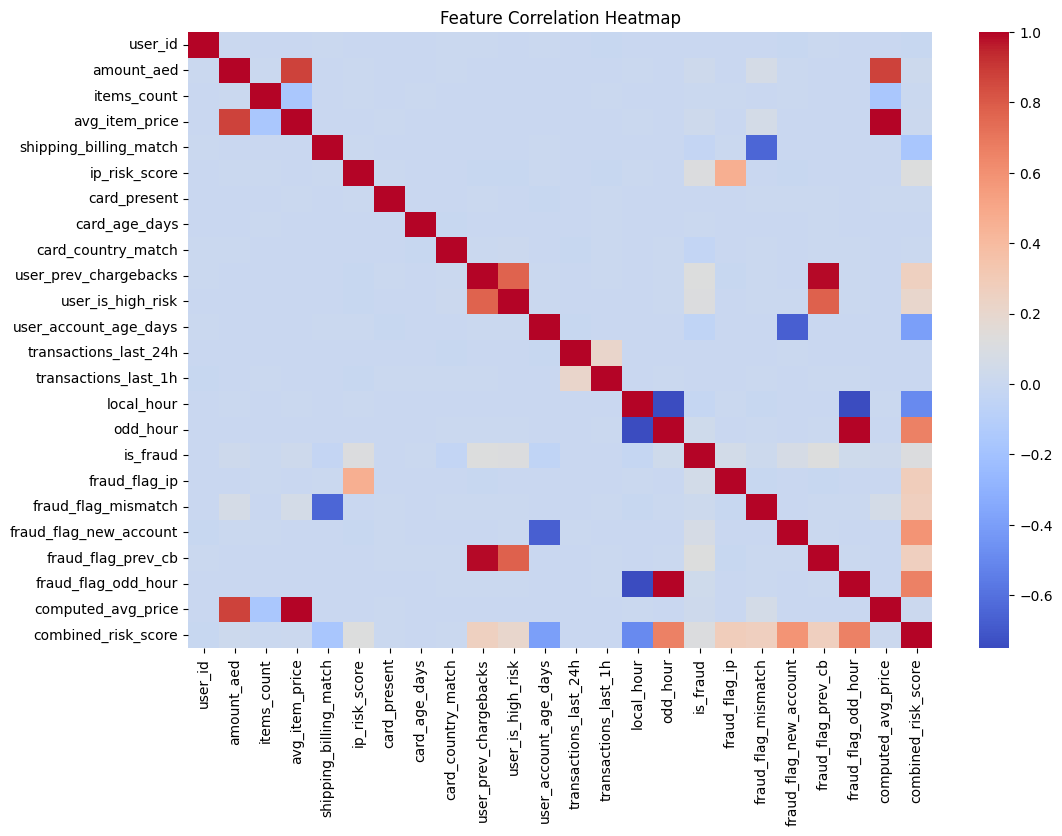

In [141]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap reveals relationships between numerical and engineered features.

- Strong correlations are observed between behavioral features such as user_prev_chargebacks and user_is_high_risk
- Fraud-related flags (fraud_flag_*) show positive correlation with is_fraud and combined_risk_score
- Velocity features (transactions_last_1h, transactions_last_24h) have weak correlation with fraud
- Amount-related features show moderate relationships, indicating spending behavior patterns
- combined_risk_score has one of the strongest correlations with fraud-related features

### 13.2 Top Correlated Features with Fraud
In this step, we identify which numerical features have the strongest positive or negative correlation with fraud. These features are potentially the most important predictors for modeling.

In [142]:
corr['is_fraud'].sort_values(ascending=False)

is_fraud                  1.00
fraud_flag_prev_cb        0.12
user_prev_chargebacks     0.12
combined_risk_score       0.12
ip_risk_score             0.12
user_is_high_risk         0.11
fraud_flag_new_account    0.08
fraud_flag_ip             0.05
fraud_flag_odd_hour       0.03
odd_hour                  0.03
amount_aed                0.03
avg_item_price            0.02
computed_avg_price        0.02
fraud_flag_mismatch       0.02
card_age_days             0.01
items_count               0.01
card_present              0.00
transactions_last_24h     0.00
transactions_last_1h     -0.00
user_id                  -0.00
local_hour               -0.02
shipping_billing_match   -0.03
card_country_match       -0.03
user_account_age_days    -0.05
Name: is_fraud, dtype: float64

Correlation with is_fraud shows that the most important features are primarily behavioral and risk-based.

- Strongest positive correlations:

-- fraud_flag_prev_cb, user_prev_chargebacks, combined_risk_score, ip_risk_score (~0.12)
-- user_is_high_risk (~0.11)
- Moderate signals:

-- fraud_flag_new_account (~0.08)
-- fraud_flag_ip (~0.05)
- Weak correlations:

-- Transaction and amount-related features (amount_aed, transactions_last_1h/24h)
- Negative correlations:

-- user_account_age_days (-0.05)
-- shipping_billing_match, card_country_match (~-0.03)

---
## 14. Multivariate Analysis 
In this step, we analyze combinations of multiple features to detect complex fraud patterns. Fraud often occurs when several risk factors appear together rather than individually.
### 14.1 Combined Risk Patterns
#### New Account + High Amount

In [143]:
df.groupby([
    'fraud_flag_new_account',
    pd.qcut(df['amount_aed'], 3)
])['is_fraud'].mean()

fraud_flag_new_account  amount_aed                
0                       (1.2590000000000001, 53.1]   0.07
                        (53.1, 128.07]               0.07
                        (128.07, 28785.92]           0.07
1                       (1.2590000000000001, 53.1]   0.13
                        (53.1, 128.07]               0.13
                        (128.07, 28785.92]           0.12
Name: is_fraud, dtype: float64

Fraud rate is significantly higher for new accounts (~13%) compared to non-new accounts (~7%), while transaction amount does not show a meaningful impact across different ranges.

#### High IP Risk + Night Transactions

In [144]:
df.groupby([
    pd.qcut(df['ip_risk_score'], 3),
    'odd_hour'
])['is_fraud'].mean()

ip_risk_score   odd_hour
(-0.001, 31.9]  0          0.05
                1          0.06
(31.9, 46.6]    0          0.07
                1          0.10
(46.6, 100.0]   0          0.11
                1          0.13
Name: is_fraud, dtype: float64

Fraud rate increases with higher IP risk scores, and is consistently higher during odd hours.

Low IP risk → ~5–6%
Medium IP risk → up to ~10%
High IP risk → up to ~13% (highest during odd hours)

#### Velocity + Mismatch

In [145]:
df.groupby([
    'transactions_last_1h',
    'shipping_billing_match'
])['is_fraud'].mean()

transactions_last_1h  shipping_billing_match
0                     0                        0.11
                      1                        0.08
1                     0                        0.00
                      1                        0.06
Name: is_fraud, dtype: float64

Fraud rate is highest when there is no recent activity and shipping/billing mismatch (~11%).
When there is recent activity (transactions_last_1h = 1), fraud rates are lower across both cases.

### 14.2 Rule-Based Simulation
#### Multiple Risk Conditions

In [146]:
df[
    (df['fraud_flag_new_account'] == 1) &
    (df['ip_risk_score'] > 70) &
    (df['odd_hour'] == 1)
]['is_fraud'].mean()

np.float64(0.27741935483870966)

Transactions that combine new accounts, high IP risk, and odd-hour activity show a significantly elevated fraud rate (~27.7%), which is much higher than the baseline (~8%).

#### Strong Risk Combination

In [147]:
df[
    (df['user_prev_chargebacks'] > 0) &
    (df['ip_risk_score'] > 70)
]['is_fraud'].mean()

np.float64(0.3258426966292135)

Transactions involving users with previous chargebacks and high IP risk show a very high fraud rate (~32.6%), significantly above the baseline.


---
## 15. Outlier Analysis
Outliers can mislead the model — we identify them before modeling to decide how to handle them.

### 15.1 amount_aed
Describe showed max 28,785 AED while 75% of transactions are below 164 AED — a huge gap worth investigating.

Q1: 41.37, Q3: 164.885, IQR: 123.51499999999999
Lower bound: -143.90249999999997, Upper bound: 350.15749999999997
Outlier count: 8627
Outlier %: 8.63%


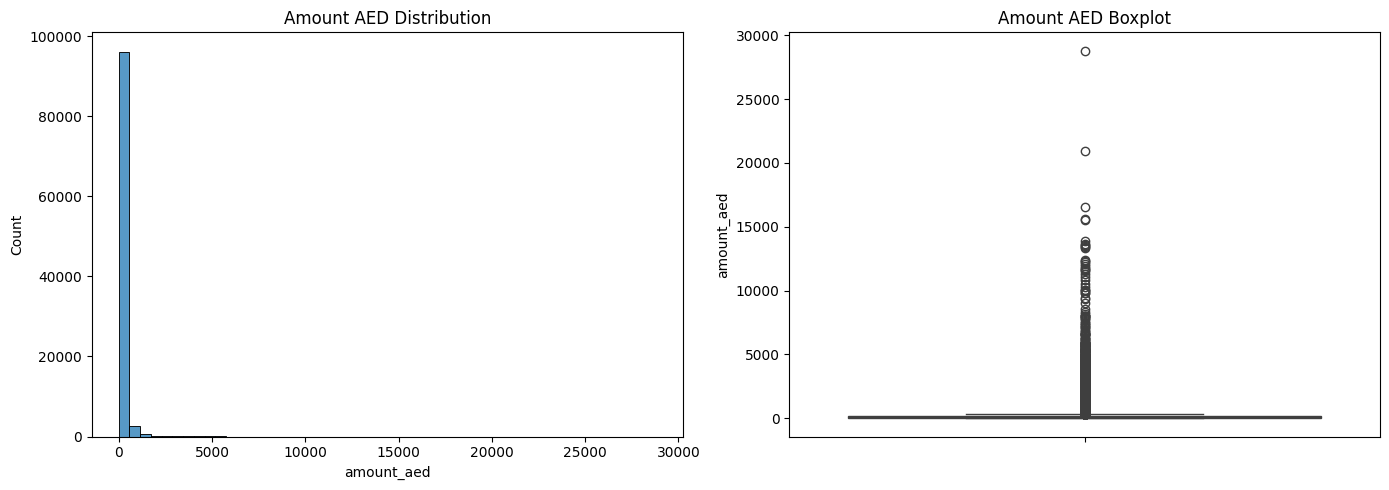

In [148]:
# Detecting outliers in amount_aed using IQR method to understand transaction amount distribution
Q1 = df['amount_aed'].quantile(0.25)
Q3 = df['amount_aed'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")
print(f"Outlier count: {((df['amount_aed'] < lower) | (df['amount_aed'] > upper)).sum()}")
print(f"Outlier %: {((df['amount_aed'] < lower) | (df['amount_aed'] > upper)).mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['amount_aed'], ax=axes[0], bins=50)
axes[0].set_title('Amount AED Distribution')
sns.boxplot(y=df['amount_aed'], ax=axes[1])
axes[1].set_title('Amount AED Boxplot')
plt.tight_layout()
plt.show()

- Distribution is heavily right-skewed — vast majority of transactions are below 350 AED
- 8.63% outliers above 350 AED — this is a significant portion, not noise
- Extreme values reach ~28,785 AED with a few isolated spikes visible in boxplot
- Since dataset documentation confirmed amount > 2,000 AED is a fraud signal, these outliers carry predictive value — we will not remove them, but will apply log transformation before modeling

### 15.2 card_age_days
card_age_days showed min 0, max 2,728 days in describe — checking if extreme values are anomalies or meaningful signals.

Q1: 219.0, Q3: 758.0, IQR: 539.0
Lower bound: -589.5, Upper bound: 1566.5
Outlier count: 981
Outlier %: 0.98%


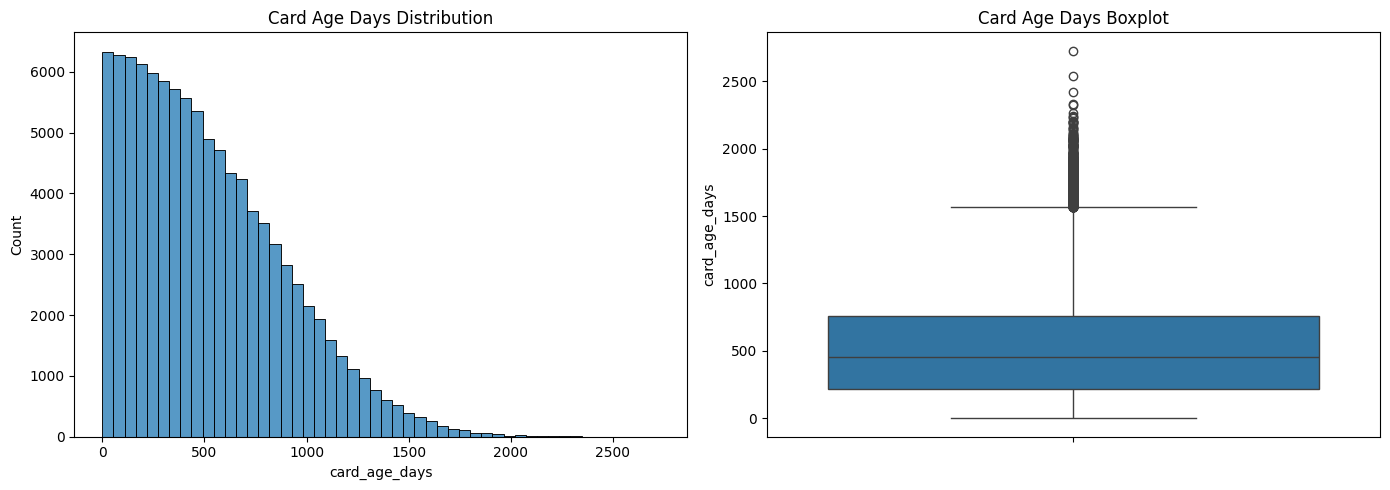

In [149]:
# Detecting outliers in card_age_days using IQR method
Q1 = df['card_age_days'].quantile(0.25)
Q3 = df['card_age_days'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")
print(f"Outlier count: {((df['card_age_days'] < lower) | (df['card_age_days'] > upper)).sum()}")
print(f"Outlier %: {((df['card_age_days'] < lower) | (df['card_age_days'] > upper)).mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['card_age_days'], ax=axes[0], bins=50)
axes[0].set_title('Card Age Days Distribution')
sns.boxplot(y=df['card_age_days'], ax=axes[1])
axes[1].set_title('Card Age Days Boxplot')
plt.tight_layout()
plt.show()

- Distribution is right-skewed but much more natural than amount_aed — gradual decline, no extreme spikes
- Only 0.98% outliers above 1,566 days (~4.3 years) — very small portion
- Lower bound is negative (-589.5) meaning no low-end outliers exist
- These high values (~2,500+ days) could represent long-standing customers — not necessarily fraud signals, but worth keeping as card age is a legitimate feature